# AEP and Gradients estimations

Here a step by step guide to all of the basic FLOWERS functionalities, consisting of the computation of wind farm AEP, gradients, specific turbine AEP and plotting. This section introduces the functionalities for NO Jensen (NOJ), Bastankhah Porte-Agel (BPA) and Nygaard TurbOPark (NTP). Given the more complex intricacies and options offered by fuga FLOWERS, these are explained in a different section.

Import FLOWERS wind farm models for different deficit models

In [1]:
from FLOWERS.noj import NOJ_flowers
from FLOWERS.bastankhah import gaussian_flowers
from FLOWERS.turbopark import TurbOPark_flowers

Other imports needed

In [2]:
from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80
import time

# Ignore numerical errors coming from FLOWERS (division by zero, etc.)
import warnings
warnings.filterwarnings("ignore")

c:\Users\janbu\AppData\Local\anaconda3\envs\flowers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initialize AEP conditions
FLOWERS uses for the wind conditions the `site` object from `PyWake`, containing the wind direction probability, as well as the wind speed Weibull distribution. FLOWERS assumes atmohsperic homogeneity, meaning that these parameters remain constant throughout the entire wind farm, and it does not consider terrain effects. Moreover, it also uses the `turbine` object used in `PyWake`.

In [3]:
site = Hornsrev1Site()
turbine = V80()
x, y = site.initial_position.T

# Wake expansion coefficients
k_NOJ = 0.04
k_gaussian = 0.03

# Turbulence intensity for TurbOPark model
TI = 0.1

## Create wind farm models
The number of Fourier terms (`n_terms`) determines the accuracy of the model, as well as the computational time. A value of `n_terms = 10` is recommened by the original paper as the balance between the two. The maximum number of Fourier modes is given by the number of wind directions in the windrose, and is obtained as `N_wd//2 + 1`. `HornsrevSite` has 12 wind direction bins, so in this case, the maximum number is 7.

In [4]:
# NO Jensen wake model
wfm_NOJ = NOJ_flowers(site = site,
                      windTurbines = turbine,
                      k = k_NOJ,
                      n_terms = 7)

# Gaussian wake model
wfm_BPA = gaussian_flowers(site = site,
                            windTurbines = turbine,
                            k = k_gaussian,
                            n_terms = 7)

# TurbOPark model
wfm_NTP = TurbOPark_flowers(site = site,
                            windTurbines = turbine,
                            n_terms = 7,
                            ti = TI)

## Compute wind farm AEP
The wind farm AEP is computed for a set of x and y coordinates defining the wind turbine positions, by means of the `aep` function. NOJ and NTP FLOWERS have been found to underestimate AEP, while BPA is known to overestimate it. FLOWERS is not meant to compute AEP accurately, but to reflect the windfarm's dynamics for layout optimization purposes.

In [ ]:
time_i = time.time()
AEP_NOJ = wfm_NOJ.aep(x, y)
print(f"AEP NOJ: {AEP_NOJ:.2f} GWh")
print(f"Time taken for NOJ AEP calculation: {time.time() - time_i:.2f} seconds")

time_i = time.time()
AEP_BPA = wfm_BPA.aep(x, y)
print(f"AEP BPA: {AEP_BPA:.2f} GWh")
print(f"Time taken for BPA AEP calculation: {time.time() - time_i:.2f} seconds")

time_i = time.time()
AEP_NTP = wfm_NTP.aep(x, y)
print(f"AEP NTP: {AEP_NTP:.2f} GWh")
print(f"Time taken for NTP AEP calculation: {time.time() - time_i:.2f} seconds")

AEP NOJ: 539.52 GWh
Time taken for NOJ AEP calculation: 0.01 seconds
AEP BPA: 783.08 GWh
Time taken for BPA AEP calculation: 0.01 seconds
AEP NTP: 581.64 GWh


## Gradients
Given that the AEP is computed solving the AEP integral anallytically rather than numerically, it enables the derivation of analytical gradients.

The package can derive the gradients using automatic differentiation with the Autograd package (https://github.com/HIPS/autograd) for all FLOWERS models, but they can also be obtained by means of the analytically derived gradients.

Gradients are obtained by means of the `aep_gradient` function, using `gradient_method="Exact"` for analytical gradients and `gradient_method="Autograd"` for automatic differentiation. It can be chosen whether the user wants to return the function computing the gradients, where the `x` and `y` inputs are left as `None`, or the gradients evaluated at certain coordinates, by providing the specific coordinates. Moreover, the package supports derivation with respect to x (`wrt_arg=["x"]`), y (`wrt_arg=["y"]`) or both (`wrt_arg=["x","y"]`).

#### Using automatic differentiation

In [6]:
# --- With respect to x and y - Evaluating the gradient ---
# NOJ
daep_dx_NOJ, daep_dy_NOJ = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
# BPA
daep_dx_BPA, daep_dy_BPA = wfm_BPA.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
# NTP
daep_dx_NTP, daep_dy_NTP = wfm_NTP.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)

# --- With respect to x only - Evaluating the gradient ---
# NOJ
daep_dx_NOJ = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)
# BPA
daep_dx_BPA = wfm_BPA.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)
# NTP
daep_dx_NTP = wfm_NTP.aep_gradient(gradient_method="Autograd", wrt_arg=["x"], x=x, y=y)

# --- With respect to y only - Returning the gradient function ---
# NOJ
daep_dy_NOJ_func = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_NOJ = daep_dy_NOJ_func(x, y)
# BPA
daep_dy_BPA_func = wfm_BPA.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_BPA = daep_dy_BPA_func(x, y)
# NTP
daep_dy_NTP_func = wfm_NTP.aep_gradient(gradient_method="Autograd", wrt_arg=["y"])
daep_dy_NTP = daep_dy_NTP_func(x, y)

#### Using analytical gradients

In [7]:
# --- With respect to x and y - Evaluating the gradient ---
# NOJ
daep_dx_NOJ, daep_dy_NOJ = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
# NTP
daep_dx_NTP, daep_dy_NTP = wfm_NTP.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
# BPA
daep_dx_BPA, daep_dy_BPA = wfm_BPA.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)

# --- With respect to x only - Evaluating the gradient ---
# NOJ
daep_dx_NOJ = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x"], x=x, y=y)
# NTP
daep_dx_NTP = wfm_NTP.aep_gradient(gradient_method="Exact", wrt_arg=["x"], x=x, y=y)
# BPA
daep_dx_BPA = wfm_BPA.aep_gradient(gradient_method="Exact", wrt_arg=["x"], x=x, y=y)

# --- With respect to y only - Returning the gradient function ---
# NOJ
daep_dy_NOJ_func = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["y"])
daep_dy_NOJ = daep_dy_NOJ_func(x, y)
# NTP
daep_dy_NTP_func = wfm_NTP.aep_gradient(gradient_method="Exact", wrt_arg=["y"])
daep_dy_NTP = daep_dy_NTP_func(x, y)
# BPA
daep_dy_BPA_func = wfm_BPA.aep_gradient(gradient_method="Exact", wrt_arg=["y"])
daep_dy_BPA = daep_dy_BPA_func(x, y)

#### Gradient methods comparison
Both Automatic and analytical differentiation are faster than other gradient computation methods such as finite differences. However there are slight numerical differences between the two in the case of NOJ FLOWERS

In [8]:
# Gradient for NOJ using analytical gradients
time_i = time.time()
daep_dx_exact, daep_dy_exact = wfm_NOJ.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for exact gradient: {time_f - time_i:.4f} seconds")

# Gradient for NOJ using autograd
time_i = time.time()
daep_dx_auto, daep_dy_auto = wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for autograd gradient: {time_f - time_i:.4f} seconds")

print("\nComparing gradients for NOJ model:")
print("Gradient (Exact) - daep_dx:", daep_dx_exact[:3])
print("Gradient (Exact) - daep_dy:", daep_dy_exact[:3])
print("Gradient (Autograd) - daep_dx:", daep_dx_auto[:3])
print("Gradient (Autograd) - daep_dy:", daep_dy_auto[:3])

Time taken for exact gradient: 0.0158 seconds
Time taken for autograd gradient: 0.0143 seconds

Comparing gradients for NOJ model:
Gradient (Exact) - daep_dx: [-0.00272678 -0.00297185 -0.00308627]
Gradient (Exact) - daep_dy: [0.00247404 0.00082243 0.00024209]
Gradient (Autograd) - daep_dx: [-0.00272952 -0.00297314 -0.00308732]
Gradient (Autograd) - daep_dy: [0.00247518 0.00082432 0.00024409]


In [ ]:
# Gradient for NTP using analytical gradients
time_i = time.time()
daep_dx_exact, daep_dy_exact = wfm_NTP.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for exact gradient: {time_f - time_i:.4f} seconds")

# Gradient for NTP using autograd
time_i = time.time()
daep_dx_auto, daep_dy_auto = wfm_NTP.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for autograd gradient: {time_f - time_i:.4f} seconds")

print("\nComparing gradients for NTP model:")
print("Gradient (Exact) - daep_dx:", daep_dx_exact[:3])
print("Gradient (Exact) - daep_dy:", daep_dy_exact[:3])
print("Gradient (Autograd) - daep_dx:", daep_dx_auto[:3])
print("Gradient (Autograd) - daep_dy:", daep_dy_auto[:3])

Time taken for exact gradient: 0.0209 seconds
Time taken for autograd gradient: 0.0156 seconds

Comparing gradients for TurbOPark model:
Gradient (Exact) - daep_dx: [-0.00205781 -0.00224704 -0.00234053]
Gradient (Exact) - daep_dy: [0.0018148  0.00068385 0.00026471]
Gradient (Autograd) - daep_dx: [-0.00205781 -0.00224704 -0.00234053]
Gradient (Autograd) - daep_dy: [0.0018148  0.00068385 0.00026471]


In [ ]:
# Gradient for BPA using analytical gradients
time_i = time.time()
daep_dx_exact, daep_dy_exact = wfm_BPA.aep_gradient(gradient_method="Exact", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for exact gradient: {time_f - time_i:.4f} seconds")

# Gradient for BPA using autograd
time_i = time.time()
daep_dx_auto, daep_dy_auto = wfm_BPA.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)
time_f = time.time()
print(f"Time taken for autograd gradient: {time_f - time_i:.4f} seconds")

print("\nComparing gradients for BPA model:")
print("Gradient (Exact) - daep_dx:", daep_dx_exact[:3])
print("Gradient (Exact) - daep_dy:", daep_dy_exact[:3])
print("Gradient (Autograd) - daep_dx:", daep_dx_auto[:3])
print("Gradient (Autograd) - daep_dy:", daep_dy_auto[:3])

Time taken for exact gradient: 0.0078 seconds
Time taken for autograd gradient: 0.0099 seconds

Comparing gradients for Gaussian model:
Gradient (Exact) - daep_dx: [-9.78874559e-07 -1.06349596e-06 -1.08202641e-06]
Gradient (Exact) - daep_dy: [6.85012375e-07 1.48439755e-07 1.14334188e-08]
Gradient (Autograd) - daep_dx: [-9.78874559e-07 -1.06349596e-06 -1.08202641e-06]
Gradient (Autograd) - daep_dy: [6.85012375e-07 1.48439755e-07 1.14334188e-08]


## AEP for a specific turbine
FLOWERS supports the calculation of the AEP for a specific wind turbine in the wind farm, using the `aep_i` function.

(It should be checked how useful this is, especially for Gaussian)

In [11]:
turbine_number = 63

# NO Jensen AEP for turbine 63
aep_63_NOJ = wfm_NOJ.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using NOJ: {aep_63_NOJ:.2f} GWh")

# Gaussian Bastankhah AEP for turbine 63
aep_63_gaussian = wfm_BPA.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using Gaussian: {aep_63_gaussian:.2f} GWh")

# TurbOPark AEP for turbine 63
aep_63_TurbOPark = wfm_NTP.aep_i(x, y)[turbine_number]
print(f"AEP for turbine {turbine_number} using TurbOPark: {aep_63_TurbOPark:.2f} GWh")

AEP for turbine 63 using NOJ: 7.48 GWh
AEP for turbine 63 using Gaussian: 9.79 GWh
AEP for turbine 63 using TurbOPark: 7.85 GWh


#### Plotting AEP for each turbine

It is possible to plot the wind farm and the AEP coming from each turbine using the `plot_AEP_per_turbine` function.

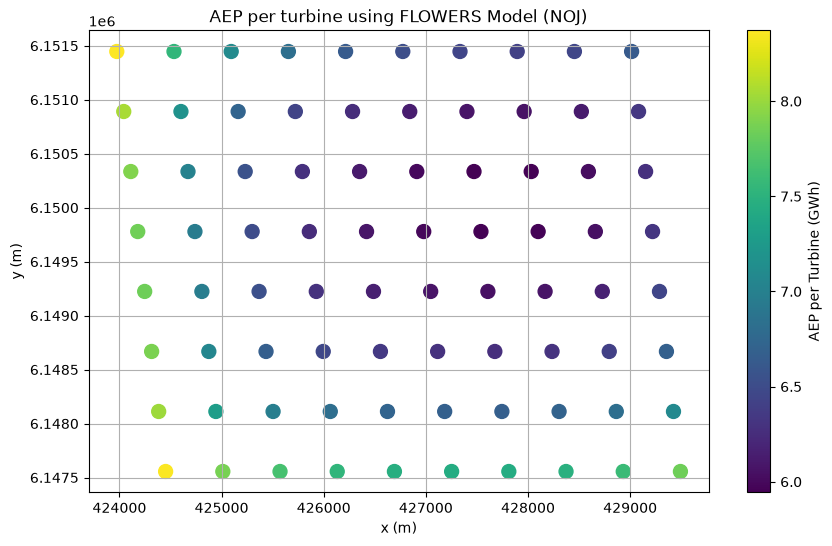

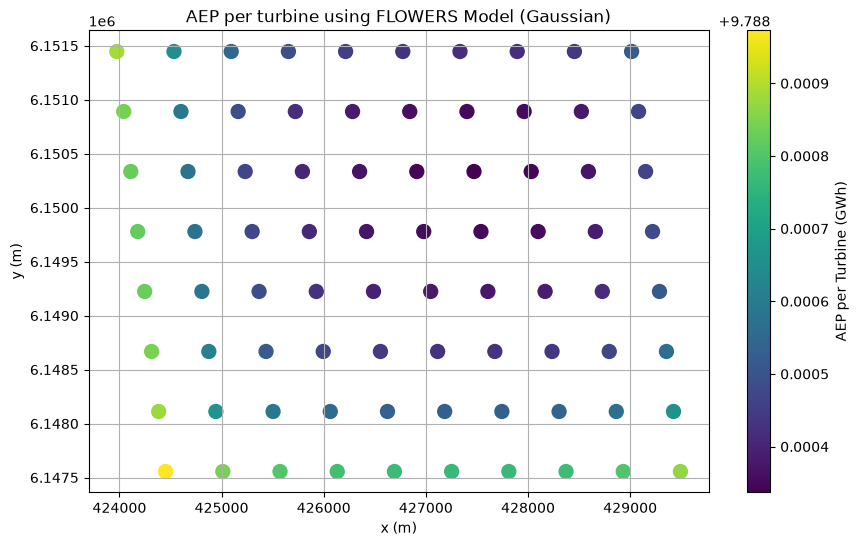

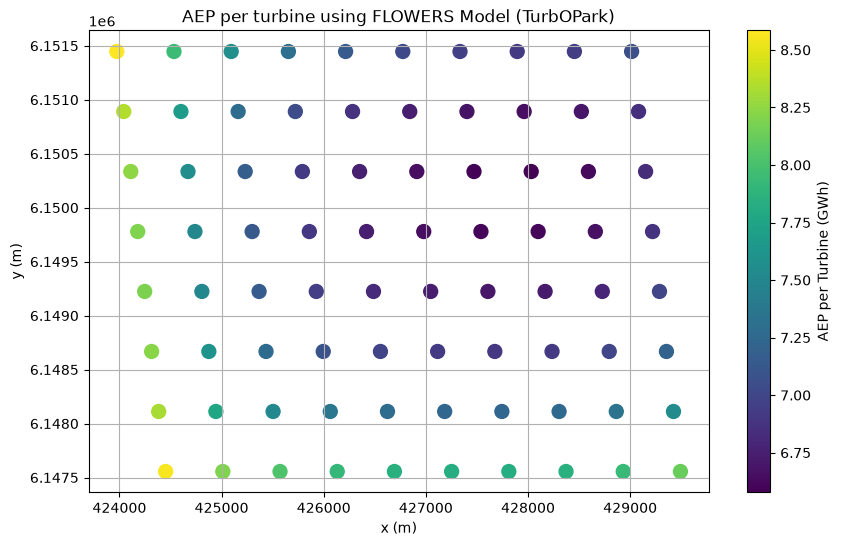

In [12]:
# Plotting AEP per turbine for NOJ model
wfm_NOJ.plot_AEP_per_turbine(x, y)

# Plotting AEP per turbine for Gaussian model
wfm_BPA.plot_AEP_per_turbine(x, y)

# Plotting AEP per turbine for TurbOPark model
wfm_NTP.plot_AEP_per_turbine(x, y)